In [ ]:
import os
import sys
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# Basic jax import
jax.config.update("jax_enable_x64", True)

# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("/home/louis/code/amigo_project/notebooks")
else:
    os.chdir("/Users/louis/PhD/Software/sandbox/amigo_project/notebooks")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ["..", "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno_r = mpl.colormaps["inferno_r"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)
inferno_r.set_bad("k", 0.5)

def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

# Load the known binaries depending on the data set

In [4]:
# VLBI orbital predictions
summary_dict = {
    "Δ RA b": [-43.3902055225921, 0.07792316, -0.06852391],
    "Δ Dec b": [190.8968588083878, 0.05921467, -0.05649594],
    "Δ RA c": [-1.3114092483845687, 0.32846866, -0.30574056],
    "Δ Dec c": [-87.17614872864965, 0.84011733, -0.75289016],
}

In [5]:
binaries = [
    (summary_dict["Δ RA b"][0], summary_dict["Δ Dec b"][0]),  # HD206893 b
    (summary_dict["Δ RA c"][0], summary_dict["Δ Dec c"][0]),  # HD206893 c
]

companions = {
    "b": binaries[0],
    "c": binaries[1],
}
fluxes = {
    "b": (-5, -2),  # HD206893 b
    "c": (-5, -2),  # HD206893 c
}

priors = {
    "b": {"astrometry": companions["b"], "photometry": fluxes["b"]},
    "c": {"astrometry": companions["c"], "photometry": fluxes["c"]},
}

priors

{'b': {'astrometry': (-43.3902055225921, 190.8968588083878),
  'photometry': (-5, -2)},
 'c': {'astrometry': (-1.3114092483845687, -87.17614872864965),
  'photometry': (-5, -2)}}

# Load the visibilities and analyse it

In [ ]:
import dLux.utils as dlu
from amigo.misc import tqdm
from amigo.vis_analysis import AmigoOIData, analyse_vis

# Circle making function
make_circle = lambda position, diameter, **kwargs: mpl.patches.Circle(
    position, diameter / 2, color="w", fill=False, linewidth=2, **kwargs
)


filters = ["F380M", "F430M", "F480M"]
colors = ["tab:blue", "tab:green", "tab:orange"]

path = "../GPU_files/results"
cal_vis_outputs = np.load(f"{path}/GO1843/cal_vis.npy", allow_pickle=True).item()


# Calculate the log-likelihoods
outputs = {}
for filt, oi_data in tqdm(cal_vis_outputs.items()):
    outputs[filt] = analyse_vis(
        AmigoOIData(oi_data),
        size=500,  # mas
        n_pts=500,  # number of points in the final grid
        n_grid=60,  # number of initial grid points
        n_batch=1,  # number of batches to calculate the likelihood
        min_flux=-6,  # minimum log flux range
        tol=1e-8,  # tolerance for the optimiser (linear OR log space)
        max_steps=512,  # maximum number of steps for the optimiser
        n_sigma=3.0,  # number of sigma for the upper limits
        log=False,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

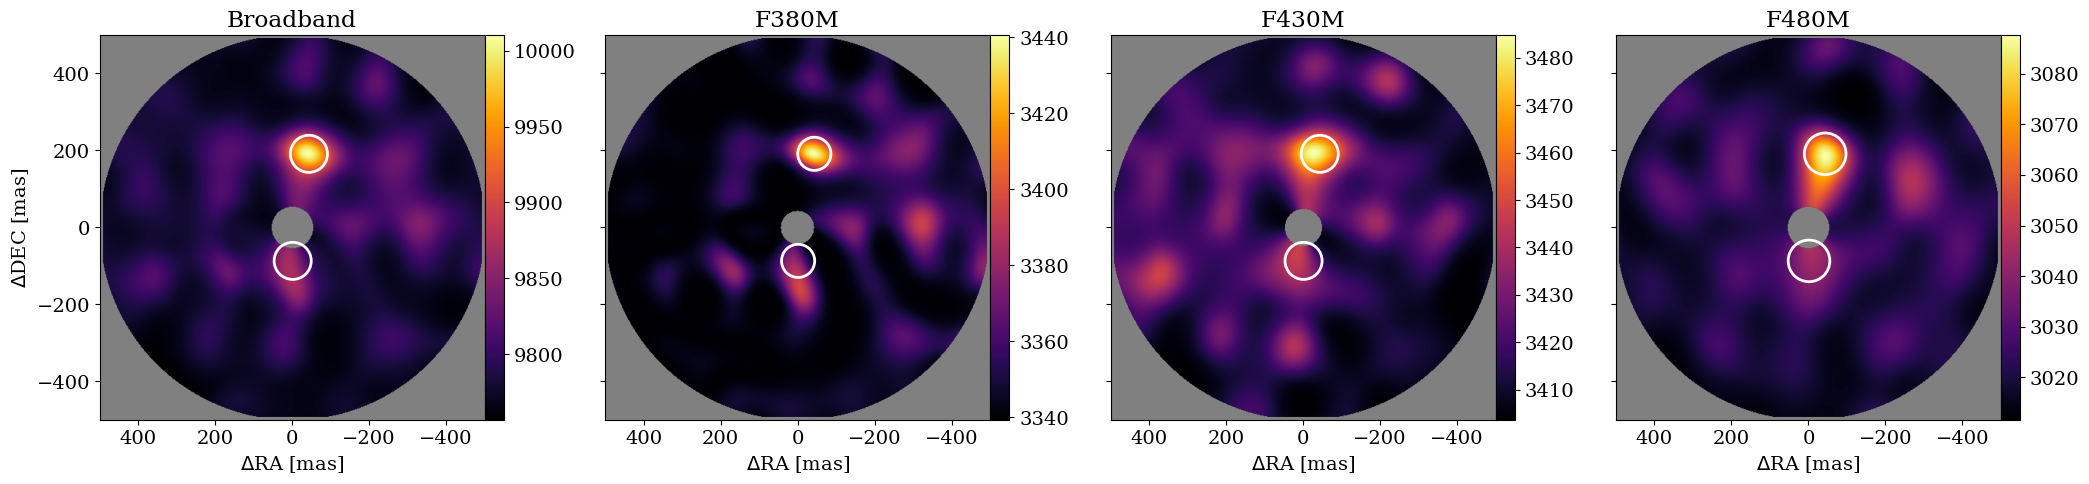

In [8]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()
bb_loglike = np.array([vals["loglike_im"] for vals in outputs.values()]).sum(0)
extent = outputs["F430M"]["extent"]
min_fov = outputs["F430M"]["fov"][0]


fig = plt.figure(figsize=(25, 5))
axes = fig.subplots(1,4, sharey=True, sharex=True)
im = axes[0].imshow(bb_loglike, cmap=inferno, aspect="equal", extent=extent)
fig.colorbar(im, cax=merge_cbar(axes[0]))
axes[0].set(
    # title="Broadband Log-Likelihood",
    title="Broadband",
    xlabel="$\\Delta$RA [mas]",
    ylabel="$\\Delta$DEC [mas]",
)

[axes[0].add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]

for i, (filt, output) in enumerate(outputs.items()):
    loglike_im = output["loglike_im"]
    contrast_im = output["contrast_im"]
    sigma_im = output["sigma_im"]
    ruffio_im = output["ruffio_im"]
    # limits_im = output["limits_im"]
    min_fov, max_fov = output["fov"]
    extent = output["extent"]
    wavel = output["oi_obj"].wavel

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        [ax.add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]

    im = axes[i+1].imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    fig.colorbar(im, cax=merge_cbar(axes[i + 1]))
    if i == 3:
        fig.colorbar(im, cax=merge_cbar(axes[i + 1]), label="Log likelihood")

    axes[i + 1].set(
        title=f"{filt}",
        xlabel="$\\Delta$RA [mas]",
    )
    add_to_ax(axes[i+1])

# Run a HMC on the known binaries

In [10]:
import numpyro as npy
import numpyro.distributions as dist
import jax.numpy as np
from amigo.vis_analysis import MultiModelCartesian

def sampling_fn(oi_objs, priors, model=MultiModelCartesian, r=75):

    dras, ddecs = [], []
    for comp, values in priors.items():
        ra, dec = values["astrometry"]

        # Define priors
        dra = npy.sample(f"Δ RA {comp}", dist.Uniform(ra - r, ra + r))
        ddec = npy.sample(f"Δ Dec {comp}", dist.Uniform(dec - r, dec + r))
        dras.append(dra)
        ddecs.append(ddec)

        # Track the outputs of the model and the PA/Sep/DMag
        _ = npy.deterministic(f"PA {comp}", dlu.rad2deg(np.arctan2(dec, dra)))
        _ = npy.deterministic(f"Sep {comp}", np.hypot(dra, ddec))
    model = model(dras, ddecs, np.zeros_like(np.array(dras)))

    pred, data, errors = [], [], []
    for filt, oi_data_obj in oi_objs.items():

        fluxes_in = []
        for comp, values in priors.items():
            log_flux = npy.sample(
                f"log Flux {comp} {filt}", dist.Uniform(*values["photometry"])
            )
            _ = npy.deterministic(f"Δ Mag {comp} {filt}", -2.5 * log_flux)
            fluxes_in.append(log_flux)
        cvis_pred = oi_data_obj.model(model.set("fluxes", 10**np.array(fluxes_in)))
        pred_data = npy.deterministic(f"pred {filt}", cvis_pred)
        pred.append(pred_data)

        # Error scales
        ones = np.ones(pred_data.size // 2)
        vis_jitter = ones * npy.sample(f"vis_jitter {filt}", dist.Uniform(-1.0, 2.0))
        phi_jitter = ones * npy.sample(f"phi_jitter {filt}", dist.Uniform(-1.0, 2.0))
        jitter = 10 ** np.concatenate([vis_jitter, phi_jitter])

        # Get and jitter the data
        cvis, d_cvis = oi_data_obj.flatten_data()
        data.append(cvis)
        errors.append(d_cvis * jitter)

    #
    data = np.concatenate(data)
    errors = np.concatenate(errors)
    pred_data = np.concatenate(pred)
    model_sampler = dist.Normal(pred_data, errors)
    return npy.sample("Sampler", model_sampler, obs=data)

In [ ]:
# Joint sampling across all filters
joint_sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=10000,
    num_samples=10000,
    num_chains=jax.device_count(),
    progress_bar=True,
)

oi_data_objs = {}
for filt, oi_data in cal_vis_outputs.items():
    oi_data_objs[filt] = AmigoOIData(oi_data)
joint_sampler.run(jr.PRNGKey(0), oi_data_objs, priors)

# Unique fit per filter
samplers = {}
for filt, oi_data in cal_vis_outputs.items():
    sampler = npy.infer.MCMC(
        npy.infer.NUTS(sampling_fn),
        num_warmup=10000,
        num_samples=10000,
        num_chains=jax.device_count(),
        progress_bar=True,
    )
    oi_objs = {filt: AmigoOIData(oi_data)}
    sampler.run(jr.PRNGKey(0), oi_objs, priors)
    samplers[filt] = sampler

sample: 100%|█| 20000/20000 [02:45<00:00, 120.54it/s, 15 steps of size 4.15e-01. acc. prob=0.9
sample: 100%|█| 20000/20000 [01:40<00:00, 198.93it/s, 15 steps of size 2.94e-01. acc. prob=0.9
sample: 100%|█| 20000/20000 [01:20<00:00, 248.87it/s, 7 steps of size 5.10e-01. acc. prob=0.87
sample: 100%|█| 20000/20000 [01:53<00:00, 176.66it/s, 15 steps of size 2.77e-01. acc. prob=0.9


In [13]:
joint_samples  = joint_sampler.get_samples()
mono_samples = {filt: sampler.get_samples() for filt, sampler in samplers.items()}

In [16]:
best_fits = {}
for companion in ["b", "c"]:
    RA = joint_samples[f"Δ RA {companion}"]
    dec = joint_samples[f"Δ Dec {companion}"]
    PA = joint_samples[f"PA {companion}"]
    Sep = joint_samples[f"Sep {companion}"]
    log_flux_f480m = joint_samples[f"log Flux {companion} F480M"]
    log_flux_f430m = joint_samples[f"log Flux {companion} F430M"]
    log_flux_f380m = joint_samples[f"log Flux {companion} F380M"]
    mag_f480m = -2.5 * log_flux_f480m
    mag_f430m = -2.5 * log_flux_f430m
    mag_f380m = -2.5 * log_flux_f380m

    best_fits[companion] = {
        "RA": f"{np.mean(RA):.3f} ± {np.std(RA):.3f} mas",
        "Dec": f"{np.mean(dec):.3f} ± {np.std(dec):.3f} mas",
        "PA": f"{np.mean(PA):.3f} ± {np.std(PA):.3f} deg",
        "Sep": f"{np.mean(Sep):.3f} ± {np.std(Sep):.3f} mas",
        "Mag F480M": f"{np.mean(mag_f480m):.3f} ± {np.std(mag_f480m):.3f}",
        "Mag F430M": f"{np.mean(mag_f430m):.3f} ± {np.std(mag_f430m):.3f}",
        "Mag F380M": f"{np.mean(mag_f380m):.3f} ± {np.std(mag_f380m):.3f}",
        
    }

for companion, fits in best_fits.items():
    print(f"Best fit {companion} astrometry:")

    for key in ["RA", "Dec", "PA", "Sep"]:
        print(key, fits[key])
    print()

    # print(f"Best fit {companion} photometry:")
    for key in ["Mag F480M", "Mag F430M", "Mag F380M"]:
        print(key, fits[key])
    print()
    print()

Best fit b astrometry:
RA -39.598 ± 3.321 mas
Dec 193.745 ± 2.847 mas
PA 101.715 ± 0.955 deg
Sep 197.780 ± 2.768 mas

Mag F480M 7.414 ± 0.078
Mag F430M 7.892 ± 0.086
Mag F380M 8.255 ± 0.137


Best fit c astrometry:
RA 12.572 ± 6.268 mas
Dec -109.986 ± 11.144 mas
PA -81.834 ± 4.018 deg
Sep 110.901 ± 10.928 mas

Mag F480M 8.256 ± 0.206
Mag F430M 8.592 ± 0.192
Mag F380M 9.343 ± 0.358




In [17]:
n_bins = 35
to_amp = lambda x: 100 * (np.exp(x) - 1)
to_phase = lambda x: dlu.rad2deg(x)

best_fits = {}
vis_analysis = {}
oi_data_objs_clean = {}
for i, (filt, oi_data_obj) in enumerate(oi_data_objs.items()):

    # Get the MCMC samples (ignore the per filter samples)
    samples = joint_samples

    # Get the MCMC sample predictions
    posterior_pred = samples[f"pred {filt}"]
    posterior_mean = np.mean(posterior_pred, axis=0)
    posterior_std = np.std(posterior_pred, axis=0)
    n = len(oi_data_obj.vis)

    # Get the MCMC error term
    vis_jitter = 10 ** samples[f"vis_jitter {filt}"].mean()
    phi_jitter = 10 ** samples[f"phi_jitter {filt}"].mean()
    d_vis = vis_jitter * oi_data_obj.d_vis
    d_phi = phi_jitter * oi_data_obj.d_phi

    vis_analysis[filt] = {
        "vis_pred": to_amp(posterior_mean[:n]),
        "vis_std": to_amp(posterior_std[:n]),
        "vis": to_amp(oi_data_obj.vis),
        "d_vis": to_amp(d_vis),
        "phi_pred": to_phase(posterior_mean[n:]),
        "phi_std": to_phase(posterior_std[n:]),
        "phi": to_phase(oi_data_obj.phi),
        "d_phi": to_phase(d_phi),
        "vis_jitter": vis_jitter,
        "phi_jitter": phi_jitter,
    }

    # Subtract off the MLE, for later re-analysis
    vis = oi_data_obj.vis - posterior_mean[:n]
    phi = oi_data_obj.phi - posterior_mean[n:]
    d_vis = np.hypot(d_vis, posterior_std[:n])
    d_phi = np.hypot(d_phi, posterior_std[n:])

    oi_data_objs_clean[filt] = oi_data_obj.set(
        ["vis", "d_vis", "phi", "d_phi"], [vis, d_vis, phi, d_phi]
    )

# Let have a look how well our samples fit our data

RMS residual / median data error
F480M:
  Vis: 1.1824 - 0.3720 - 0.3146
  Phi: 1.0286 - 0.1470 - 0.1429
0.5
F430M:
  Vis: 1.0448 - 0.1788 - 0.1711
  Phi: 1.0845 - 0.1014 - 0.0935
0.425
F380M:
  Vis: 1.1352 - 0.1835 - 0.1616
  Phi: 1.0355 - 0.0923 - 0.0891
0.35


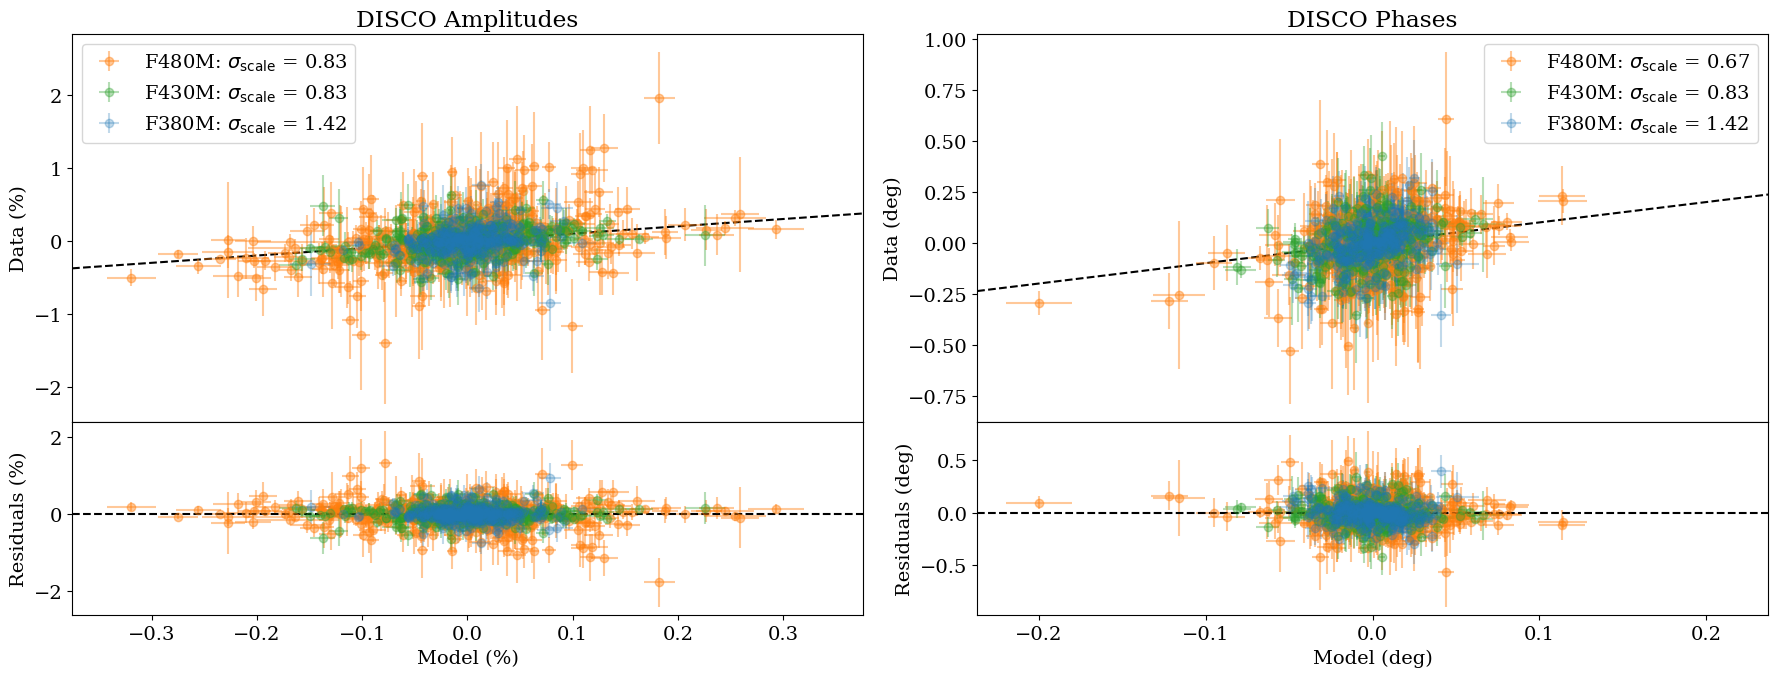

In [18]:
from matplotlib.gridspec import GridSpec
from amigo.stats import chi2, bin_data

# Create a 2x2 grid with shared x-axes in columns
correlation_fig = plt.figure(figsize=(18, 7))

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = correlation_fig.add_subplot(gs[0, 0])
ax2 = correlation_fig.add_subplot(gs[0, 1])

# Residual plots
res1 = correlation_fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = correlation_fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

alpha = 0.5
for i, (c, filt) in enumerate(zip(reversed(colors), reversed(filters))):
    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.4f} - {rms(vis_pred - vis):.4f} - {med_err(d_vis):.4f}")
    print(f"  Phi: {phi_precision:.4f} - {rms(phi_pred - phi):.4f} - {med_err(d_phi):.4f}")

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=alpha, color=c, **kwargs
    )
    print(alpha)
    alpha -= 0.075

    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt}: $\sigma_{{\text{{scale}}}}$ = {vis_jitter:.2f}")

    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt}: $\sigma_{{\text{{scale}}}}$ = {phi_jitter:.2f}")

ax1.set(title="DISCO Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
ax2.set(title="DISCO Phases", ylabel="Data (deg)", xlabel="Model (deg)")

res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")

res1.axhline(0, color="k", ls="--")
res2.axhline(0, color="k", ls="--")

ax1.legend()
ax2.legend()

# Now add 1:1 lines that span the full horizontal axis
for ax in [ax1, ax2]:
    xmax = np.abs(np.array(ax.get_xlim())).max()
    xlims = (-xmax, xmax)
    ax.plot(xlims, xlims, "k--", zorder=0)
    ax.set_xlim(xlims)

correlation_fig.tight_layout()
correlation_fig.show()

RMS residual / median data error
F480M:
  Vis: 1.01 - 0.08 - 0.08
  Phi: 1.21 - 0.04 - 0.03
F430M:
  Vis: 1.26 - 0.05 - 0.04
  Phi: 1.35 - 0.03 - 0.02
F380M:
  Vis: 0.96 - 0.04 - 0.04
  Phi: 1.42 - 0.03 - 0.02


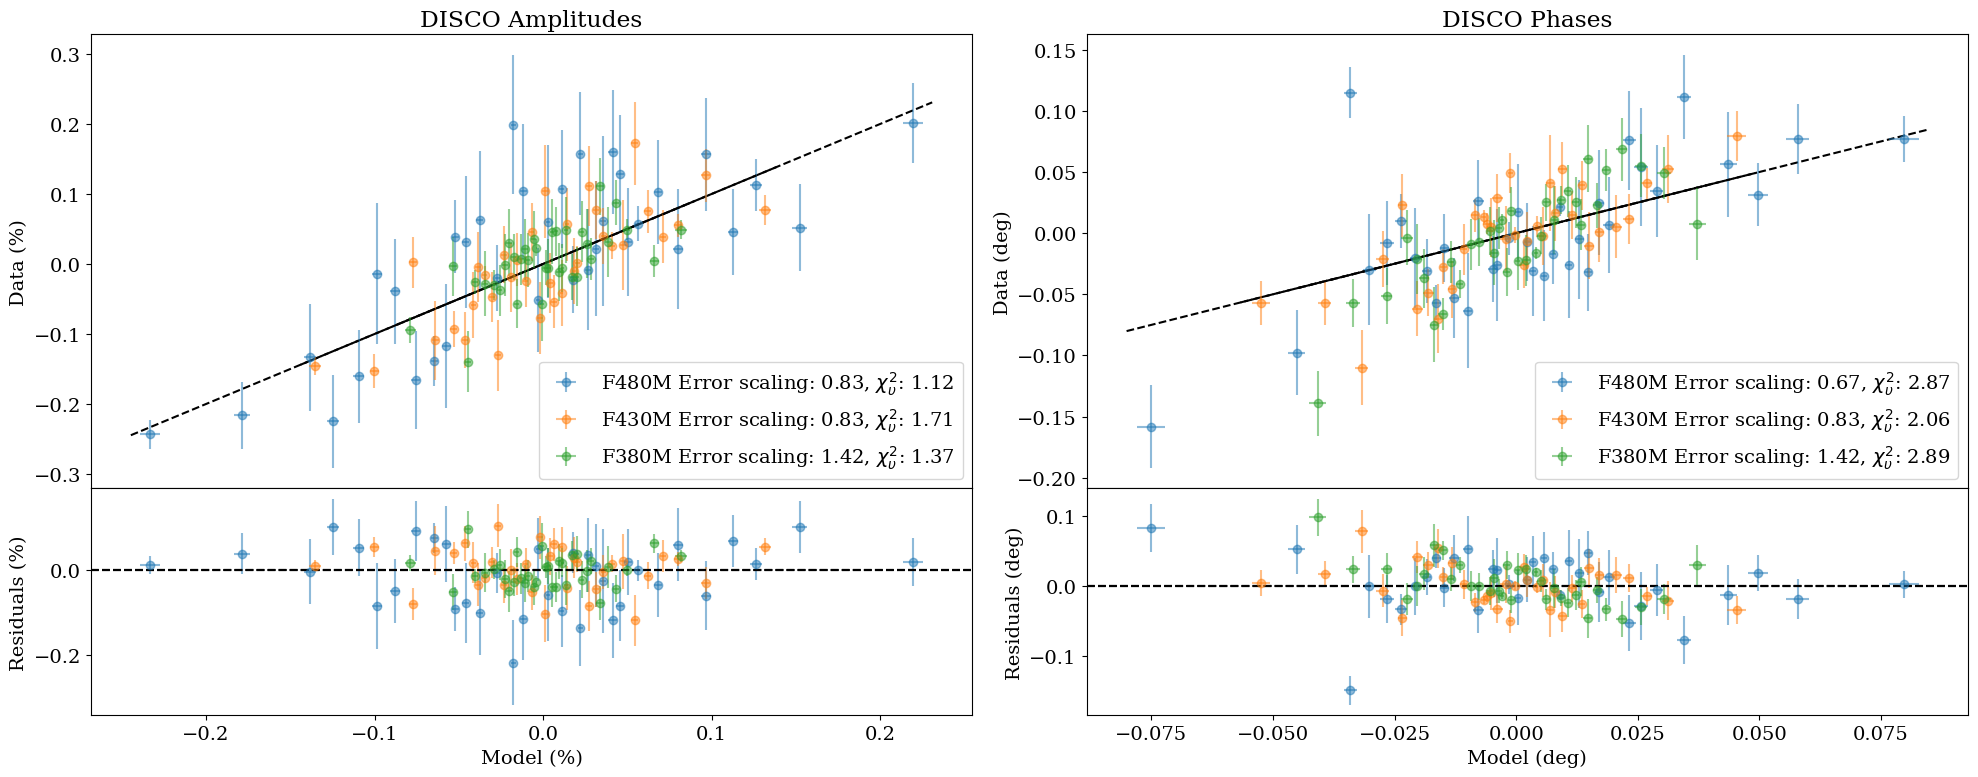

In [19]:
# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")
for i, filt in enumerate(["F480M", "F430M", "F380M"]):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]


    # Bin the visibilities
    bin_inds = np.array_split(np.argsort(vis_pred), n_bins)
    vis_pred, vis_std = bin_data(vis_pred, vis_std, bin_inds)
    vis, d_vis = bin_data(vis, d_vis, bin_inds)

    # Bin the phases
    bin_inds = np.array_split(np.argsort(phi_pred), n_bins)
    phi_pred, phi_std = bin_data(phi_pred, phi_std, bin_inds)
    phi, d_phi = bin_data(phi, d_phi, bin_inds)

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.5, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="DISCO Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="DISCO Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

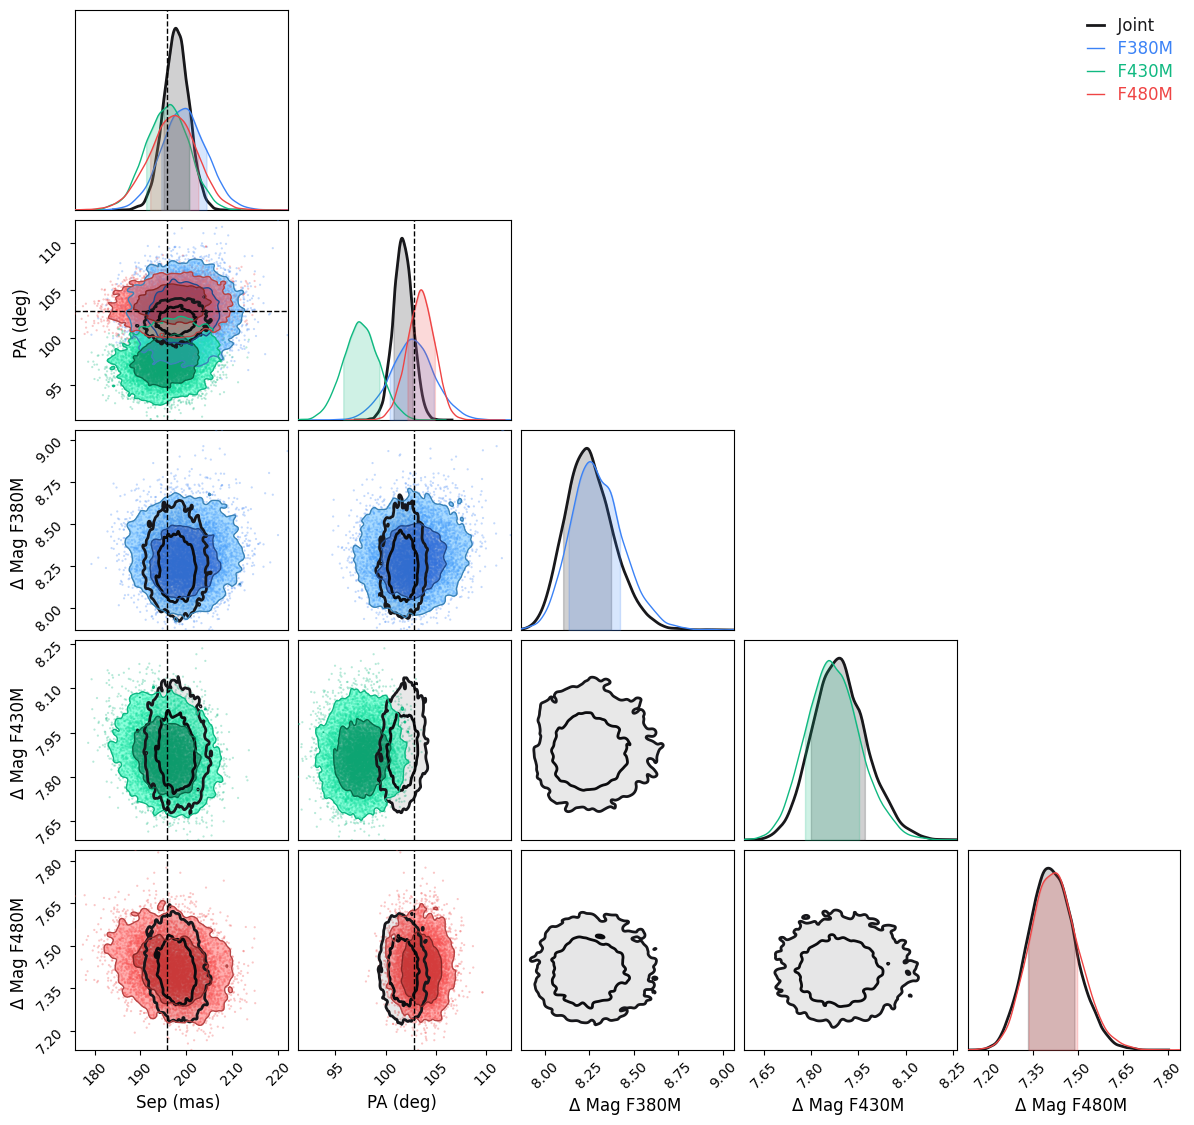

In [20]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

true_ra, true_dec = binaries[0]

c = ChainConsumer()
truths = {
    "Δ Dec (mas)": true_dec,
    "Δ RA (mas)": true_ra,
    "Sep (mas)": np.hypot(true_ra, true_dec),
    "PA (deg)": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}
c.add_truth(Truth(location=truths))

# # Cartesian
# params = ["Δ RA b", "Δ Dec b"]
# keys = ["Δ RA (mas)", "Δ Dec (mas)"]

# Polar
params = ["Sep b", "PA b"]
keys = ["Sep (mas)", "PA (deg)"]


_params = params + [f"Δ Mag b {filt}" for filt in vis_analysis.keys()]
_keys = keys + [f"Δ Mag {filt}" for filt in vis_analysis.keys()]

results = {key: joint_samples[param] for key, param in zip(_keys, _params)}
c.add_chain(
    Chain(
        samples=pd.DataFrame.from_dict(results),
        name="Joint",
        plot_cloud=False,
        marker_style="*",
        marker_size=100,
        color="k",  # black line
        shade=True,  # no fill
        linewidth=2.,  # thicker contour
        shade_alpha=0.1,  # transparent fill
    )
)

for filt in vis_analysis.keys():
    _params = params + [f"Δ Mag b {filt}"]
    _keys = keys + [f"Δ Mag {filt}"]

    results = {key: mono_samples[filt][param] for key, param in zip(_keys, _params)}
    c.add_chain(
        Chain(
            samples=pd.DataFrame.from_dict(results),
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )


fig1 = c.plotter.plot()
plt.show()

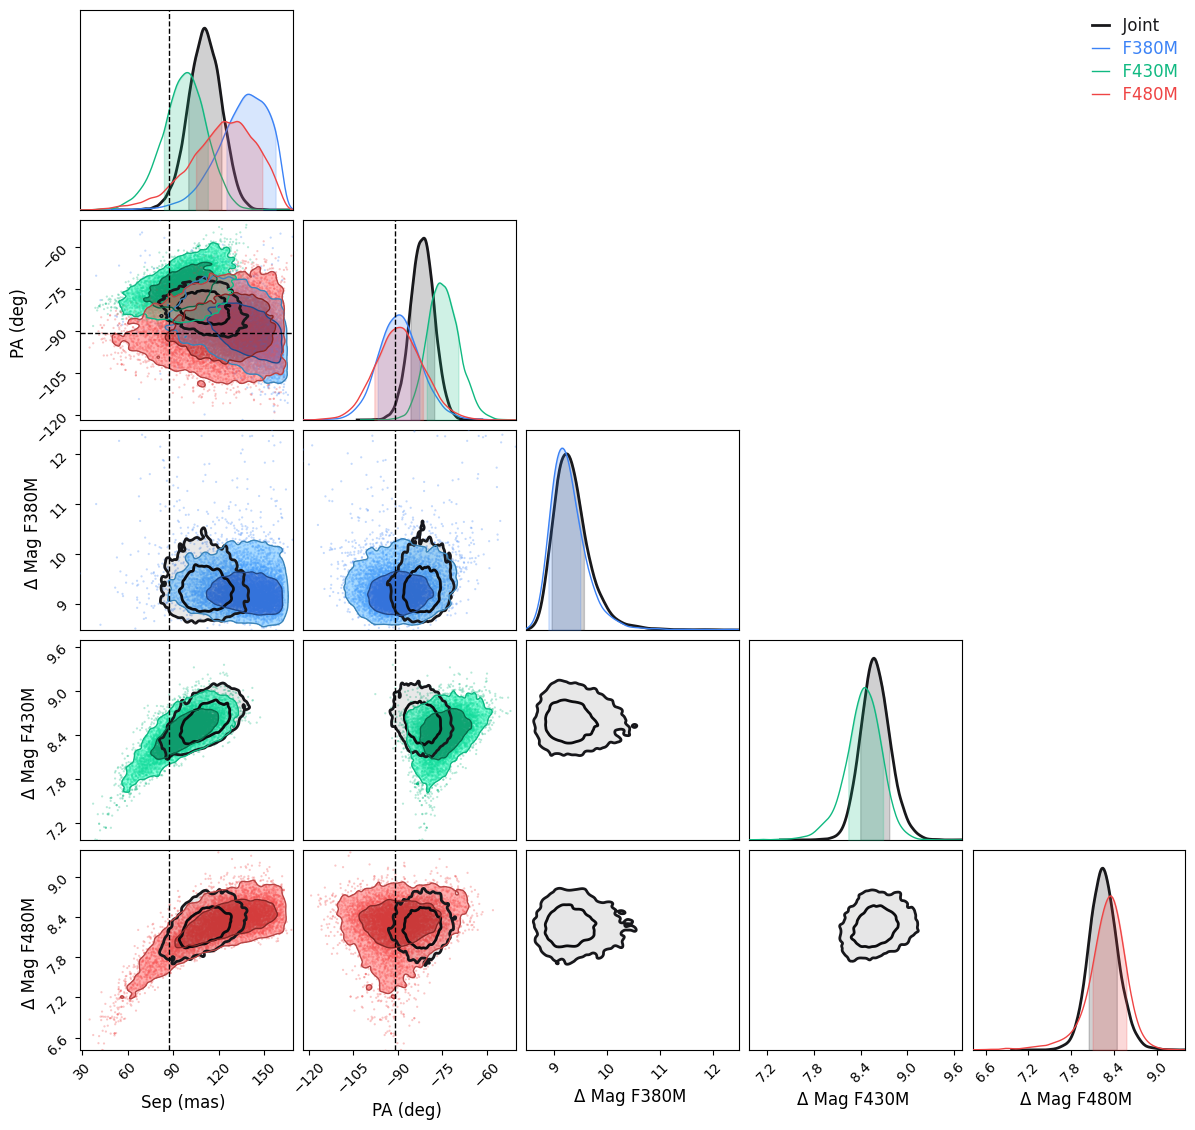

In [21]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

true_ra, true_dec = binaries[1]

c = ChainConsumer()
truths = {
    "Δ Dec (mas)": true_dec,
    "Δ RA (mas)": true_ra,
    "Sep (mas)": np.hypot(true_ra, true_dec),
    "PA (deg)": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}
c.add_truth(Truth(location=truths))

# # Cartesian
# params = ["Δ RA b", "Δ Dec b"]
# keys = ["Δ RA (mas)", "Δ Dec (mas)"]

# Polar
params = ["Sep c", "PA c"]
keys = ["Sep (mas)", "PA (deg)"]


_params = params + [f"Δ Mag c {filt}" for filt in vis_analysis.keys()]
_keys = keys + [f"Δ Mag {filt}" for filt in vis_analysis.keys()]
results = {key: joint_samples[param] for key, param in zip(_keys, _params)}
c.add_chain(
    Chain(
        samples=pd.DataFrame.from_dict(results),
        name="Joint",
        plot_cloud=False,
        marker_style="*",
        marker_size=100,
        color="k",  # black line
        shade=True,  # no fill
        linewidth=2.0,  # thicker contour
        shade_alpha=0.1,  # transparent fill
    )
)

for filt in vis_analysis.keys():
    _params = params + [f"Δ Mag c {filt}"]
    _keys = keys + [f"Δ Mag {filt}"]

    results = {key: mono_samples[filt][param] for key, param in zip(_keys, _params)}
    c.add_chain(
        Chain(
            samples=pd.DataFrame.from_dict(results),
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )


fig1 = c.plotter.plot()
plt.show()

# Look at the upper limits of the data with the best-fit binaries subtracted

In [22]:
import dLux.utils as dlu
from amigo.misc import tqdm

# Calculate the log-likelihoods
cln_outputs = {}
for filt, oi_obj in tqdm(oi_data_objs_clean.items()):

    cln_outputs[filt] = analyse_vis(
        oi_obj,
        size=500,  # mas
        n_pts=500,  # number of points in the final grid
        n_grid=60,  # number of initial grid points
        n_batch=1,  # number of batches to calculate the likelihood
        min_flux=-6,  # minimum log flux range
        tol=1e-8,  # tolerance for the optimizer (linear OR log space)
        max_steps=512,  # maximum number of steps for the optimizer
        n_sigma=3.0,  # number of sigma for the upper limits
        log=False,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

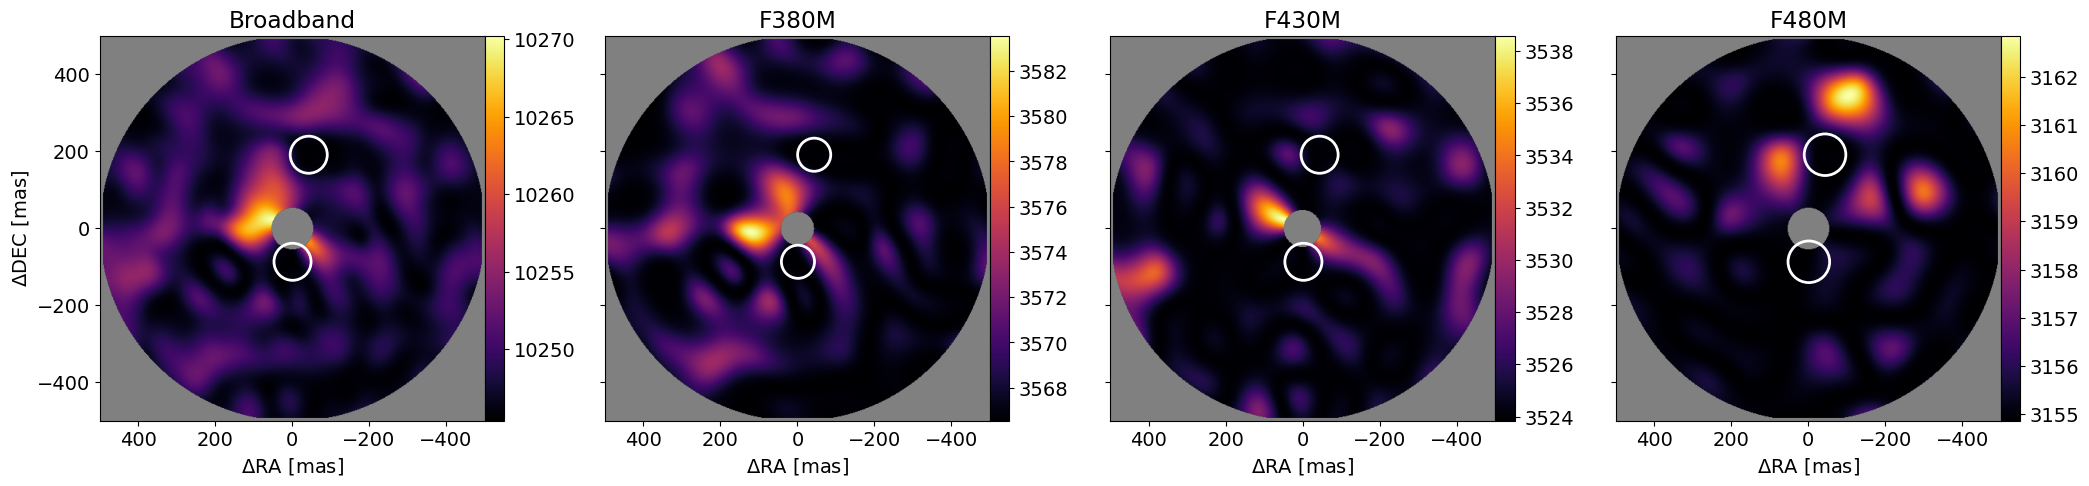

In [23]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()
bb_loglike = np.array([vals["loglike_im"] for vals in cln_outputs.values()]).sum(0)
extent = cln_outputs["F430M"]["extent"]
min_fov = cln_outputs["F430M"]["fov"][0]


fig = plt.figure(figsize=(25, 5))
axes = fig.subplots(1, 4, sharey=True, sharex=True)
im = axes[0].imshow(bb_loglike, cmap=inferno, aspect="equal", extent=extent)
fig.colorbar(im, cax=merge_cbar(axes[0]))
axes[0].set(
    # title="Broadband Log-Likelihood",
    title="Broadband",
    xlabel="$\\Delta$RA [mas]",
    ylabel="$\\Delta$DEC [mas]",
)

[axes[0].add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]

for i, (filt, output) in enumerate(cln_outputs.items()):
    loglike_im = output["loglike_im"]
    contrast_im = output["contrast_im"]
    sigma_im = output["sigma_im"]
    ruffio_im = output["ruffio_im"]
    # limits_im = output["limits_im"]
    min_fov, max_fov = output["fov"]
    extent = output["extent"]
    wavel = output["oi_obj"].wavel

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        [ax.add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]

    im = axes[i + 1].imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    fig.colorbar(im, cax=merge_cbar(axes[i + 1]))
    if i == 3:
        fig.colorbar(im, cax=merge_cbar(axes[i + 1]), label="Log likelihood")

    axes[i + 1].set(
        title=f"{filt}",
        xlabel="$\\Delta$RA [mas]",
    )
    add_to_ax(axes[i + 1])

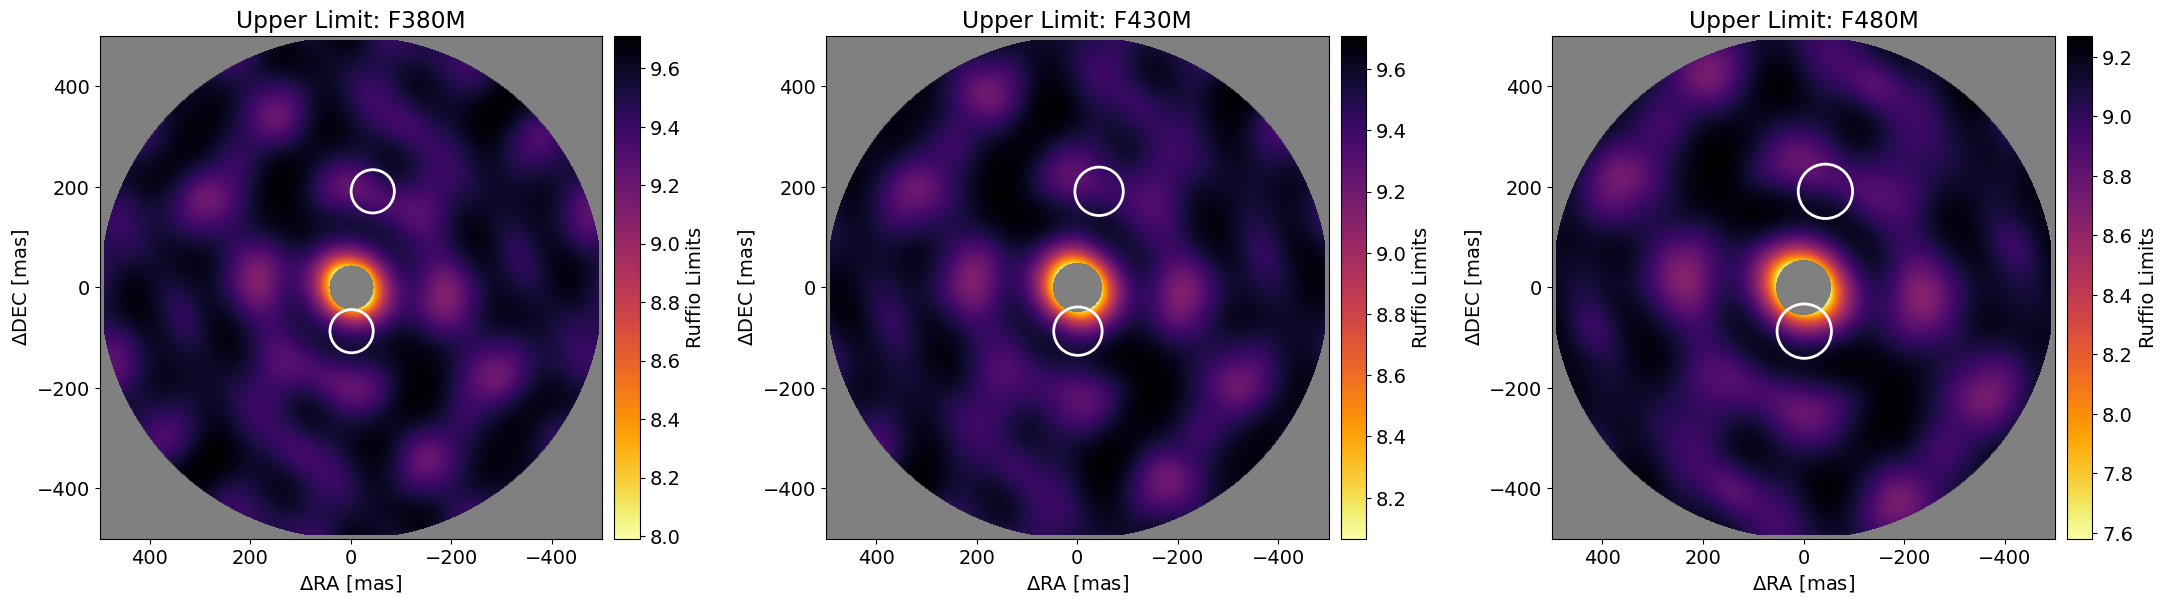

In [24]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()

plt.figure(figsize=(22, 12))
for i, (filt, output) in enumerate(cln_outputs.items()):
    loglike_im = output["loglike_im"]
    contrast_im = output["contrast_im"]
    sigma_im = output["sigma_im"]
    ruffio_im = output["ruffio_im"]
    # limits_im = output["limits_im"]
    min_fov, max_fov = output["fov"]
    extent = output["extent"]
    wavel = output["oi_obj"].wavel

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        [ax.add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]
        # ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
        # ax.legend()

    #
    ax = plt.subplot(2, 3, i + 1)
    # plt.imshow(ruffio_im, cmap=inferno, aspect="equal", extent=extent)
    plt.imshow(-2.5 * np.log10(ruffio_im), cmap=inferno_r, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Ruffio Limits", pad=0.02)
    ax.set(
        title=f"Upper Limit: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)


plt.tight_layout()
plt.show()

In [25]:
n_phots = {
    "F380M": 5.31 * 1e9,
    "F430M": 2.47 * 1e9,
    "F480M": 1.05 * 1e9,
}

for i, (filt, output) in enumerate(cln_outputs.items()):
    
    photon_limit = -2.5 * np.log10(np.sqrt(100 / n_phots[filt]))
    print(f"{photon_limit:.2f}")

9.66
9.24
8.78


In [26]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd


# Plot polar or cartesian coordinates
polar = True

if polar:
    params = ["Sep b", "PA b"]
    keys = ["Sep (mas)", "PA (deg)"]
else:
    params = ["Δ RA b", "Δ Dec b"]
    keys = ["Δ RA (mas)", "Δ Dec (mas)"]

for filt in vis_analysis.keys():
    if polar:
        params += [f"Δ Mag b {filt}"]
        keys += [f"Δ Mag {filt}"]
    else:
        params += [f"Δ Mag b {filt}"]
        keys += [f"Δ Mag {filt}"]


results = {key: joint_samples[param] for key, param in zip(keys, params)}


In [27]:
from scipy import interpolate
import numpy as np
from astropy.convolution import convolve
from astropy.convolution import Gaussian2DKernel


# Plot polar or cartesian coordinates
params = ["Sep b", "PA b", "Sep c", "PA c"]

for filt in vis_analysis.keys():
    params += [f"Δ Mag b {filt}", f"Δ Mag c {filt}"]

results = {param: joint_samples[param] for param in params}

118.69622727389233
134.314151915194
149.93207655649556


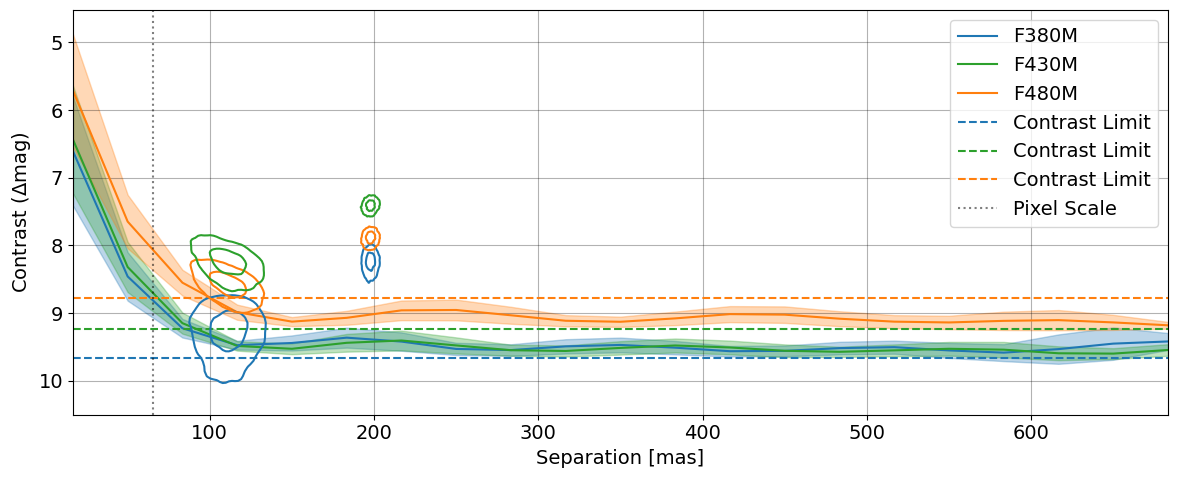

In [28]:
wavels = {
    "F380M": 3.8e-6,
    "F430M": 4.3e-6,
    "F480M": 4.8e-6,
}

for i, (filt, output) in enumerate(cln_outputs.items()):
    print(1e3 * dlu.rad2arcsec(wavels[filt] / optics.diameter))

plt.figure(figsize=(12, 5))
for i, (filt, output) in enumerate(cln_outputs.items()):
    rad_width, avg_width, std_width = output["ruffio"]
    n_sigma = output["n_sigma"]

    dx = 1000 / 60
    plt.plot(rad_width * dx, avg_width, label=f"{filt}", color=colors[i])
    plt.fill_between(
        rad_width * dx,
        avg_width - std_width,
        avg_width + std_width,
        color=colors[i],
        alpha=0.3,
    )
    plt.ylabel("Contrast ($\\Delta$mag)")
    plt.xlabel("Separation [mas]")
    plt.gca().invert_yaxis()
    plt.xlim(
        np.nanmin(rad_width * dx + avg_width * 0.0),
        np.nanmax(rad_width * dx + avg_width * 0.0),
    )
    plt.grid(color="black", alpha=0.3)

for i, (filt, output) in enumerate(cln_outputs.items()):
    photon_limit = -2.5 * np.log10(np.sqrt(100 / n_phots[filt]))
    plt.axhline(photon_limit, color=colors[i], ls="--", label="Contrast Limit")

# for i, (filt, output) in enumerate(cln_outputs.items()):
#     dlim = 1e3 * dlu.rad2arcsec(wavels[filt] / optics.diameter)
#     plt.axvline(dlim, color=colors[i], ls="-")

plt.axvline(optics.psf_pixel_scale*1e3, color="k", ls=":", alpha=0.5, label="Pixel Scale")
plt.legend(loc="best")

smooth_kernel = 1.0  # increase/decrease for smoother/rougher contours

for companion in ["b", "c"]:
    for i, filt in enumerate(["F380M", "F430M", "F480M"]):
        separation_samples = results[f"Sep {companion}"]
        contrast_samples = results[f"Δ Mag {companion} {filt}"]

        h, xedges, yedges = np.histogram2d(separation_samples, contrast_samples, bins=50)
        xbins = xedges[:-1] + (xedges[1] - xedges[0]) / 2
        ybins = yedges[:-1] + (yedges[1] - yedges[0]) / 2

        h = convolve(h.T, Gaussian2DKernel(x_stddev=smooth_kernel))

        # levels = 1.0 - np.exp(-0.5 * np.array([1.0, 2.0, 3.0]) ** 2)  # 1, 2, 3 sigma contours
        levels = 1.0 - np.exp(-0.5 * np.array([1.0, 2.0]) ** 2)  # 2 sigma contours

        h = h / np.sum(h)
        n = 100000
        t = np.linspace(0.0, h.max(), n)
        integral = ((h >= t[:, None, None]) * h).sum(axis=(1, 2))

        f = interpolate.interp1d(integral, t)
        t_contours = f(levels)

        plt.contour(xbins, ybins, h, levels=np.flip(t_contours), colors=[f"C{i}"])  # for plotting contours

plt.ylim(10.5)
plt.tight_layout()
plt.show()